In [1]:
# Dairy
# Loaded and explored the dataset Date: 28/03
# Downloaded the Jigsaw Toxic Comment Classification dataset from Kaggle and loaded the train.csv file using pandas. Viewed the data structure.
#
# Checked class distribution Date: 28/03
# Summed the label columns to see how many positive samples exist for each class.
#
# Preprocessed the text Date: 29/03
# Used the Keras TextVectorization layer. Adapted the vectoriser on the full comment column so it learns the vocabulary.
# Built the tf.data pipeline Date: 29/03
# Created a tf.data.Dataset with cache, shuffle, batch and prefetch then split the data into 70% train, 20% validation and 10% test. As a result got the cached pipeline sped up each epoch and this clean split gave me a separate test set for unbiased evaluation.
#
# Built the first LSTM model Date: 30/03
# Stacked an Embedding layer, a Bidirectional LSTM, Dense ReLU layers and a final Dense with sigmoid activation. Compiled with Adam and BinaryCrossentropy.
#
# Trained the model  Date: 30/03
# Trained for 1 epoch first then plotted training and validation loss using matplotlib.
#
# Tested predictions on example comments Date: 01/04
# Ran the model on a deliberately toxic example and on a batch from the test set. Applied a threshold to convert sigmoid outputs into binary labels.As a result, the model correctly flagged the obvious toxic example which confirmed that it is working.
#
# Evaluated with Precision, Recall and Accuracy Date: 02/04
# Looped through the test set and updated Keras Precision, Recall and CategoricalAccuracy metrics. As a result, the model achieved strong precision and recall even after a single epoch. This showed the Bidirectional LSTM was well suited to the task.
#
# Retraining Date: 05/04
# Experimented with different embedding sizes and LSTM units and tested whether adding a Dropout layer reduced overfitting on longer runs. As a result, I noticed that the larger LSTM slightly improved recall on the rare classes, while Dropout helped stabilise validation loss.


In [2]:
# installation of Dependencies and Bring in Data
import os
import pandas as pd
import numpy as np
import tensorflow as tf

In [3]:
# to confirm TensorFlow can see a GPU (training still works on CPU, just slower)
print("TensorFlow version:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow version: 2.18.1
GPU available: True


In [4]:
# to load the training data from the Kaggle Jigsaw dataset
# this CSV contains the comment text and six binary toxicity labels
df = pd.read_csv('train.csv')

# look at the first few records to confirm the data loaded correctly
print(df.head())

# to inspect shape and label distribution - useful for spotting class imbalance
print("Dataset shape:", df.shape)
print("\nLabel distribution:")
print(df[df.columns[2:]].sum())

                 id                                       comment_text  toxic  \
0  0000997932d777bf  Explanation\nWhy the edits made under my usern...      0   
1  000103f0d9cfb60f  D'aww! He matches this background colour I'm s...      0   
2  000113f07ec002fd  Hey man, I'm really not trying to edit war. It...      0   
3  0001b41b1c6bb37e  "\nMore\nI can't make any real suggestions on ...      0   
4  0001d958c54c6e35  You, sir, are my hero. Any chance you remember...      0   

   severe_toxic  obscene  threat  insult  identity_hate  
0             0        0       0       0              0  
1             0        0       0       0              0  
2             0        0       0       0              0  
3             0        0       0       0              0  
4             0        0       0       0              0  
Dataset shape: (159571, 8)

Label distribution:
toxic            15294
severe_toxic      1595
obscene           8449
threat             478
insult            7877
id

In [5]:
# 1. preprocessing
# the raw comment text must be converted to integer sequences before the neural network can consume that
# TextVectorization handles tokenisation and vocabulary
# building
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import tensorflow as tf
tf.config.set_visible_devices([], 'GPU')
from tensorflow.keras.layers import TextVectorization
X = df['comment_text']
y = df[df.columns[2:]].values

# words beyond this rank are treated as out-of-vocabulary
MAX_FEATURES = 200000
# bulding the vectorizer whree max_token s limits vocabulary size and output_sequence_length truncates every comment to multiple tokens
vectorizer = TextVectorization(max_tokens=MAX_FEATURES,
                               output_sequence_length=200,
                               output_mode='int')
vectorizer.adapt(X.values)
# transforming the whole data set so we will not tokenize each epoch
vectorized_text = vectorizer(X.values)

In [6]:
# tf.data pipeline that will consist of Map, Cache, Shuffle, Batch and Prefetch
dataset = tf.data.Dataset.from_tensor_slices((vectorized_text, y))
dataset = dataset.cache()
dataset = dataset.shuffle(160000)   # shuffle buffer
dataset = dataset.batch(32)  # mini-batch size
dataset = dataset.prefetch(8)   # overlap loading with training
# split into train, validation and test partitions
train = dataset.take(int(len(dataset) * .7))
val   = dataset.skip(int(len(dataset) * .7)).take(int(len(dataset) * .2))
test  = dataset.skip(int(len(dataset) * .9)).take(int(len(dataset) * .1))


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
3490/3490 ━━━━━━━━━━━━━━━━━━━━ 128s 36ms/step - loss: 0.0651 - val_loss: 0.0490
Epoch 2/5
3490/3490 ━━━━━━━━━━━━━━━━━━━━ 127s 36ms/step - loss: 0.0455 - val_loss: 0.0395
Epoch 3/5
3490/3490 ━━━━━━━━━━━━━━━━━━━━ 128s 37ms/step - loss: 0.0407 - val_loss: 0.0366
Epoch 4/5
3490/3490 ━━━━━━━━━━━━━━━━━━━━ 125s 36ms/step - loss: 0.0362 - val_loss: 0.0319
Epoch 5/5
3490/3490 ━━━━━━━━━━━━━━━━━━━━ 127s 36ms/step - loss: 0.0325 - val_loss: 0.0277


<Figure size 800x500 with 0 Axes>

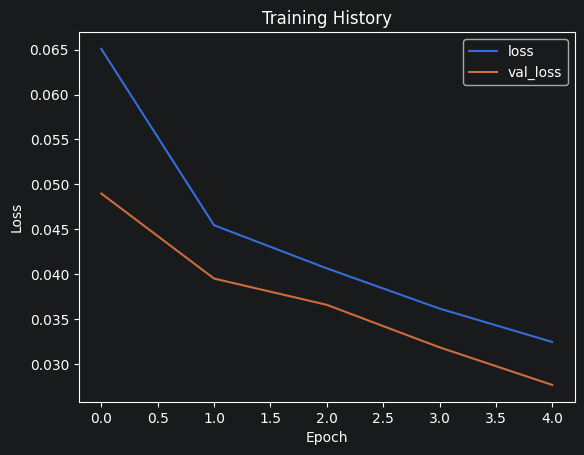

In [14]:
# 2.creating Sequential Model
# embedding will convert integer token id into dense  vectors so semantically similar words sit close together in vector space
# bidirectional LSTM will read the comments left to right and right to left giving the network contxt from both directions
# ReLU will act as a feature extractor on top of the sequence output
# and Sigmoid is used and not softmax since we want labels that will not be mutually exclusive

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Bidirectional, Dense, Embedding
model = Sequential()
model.add(Embedding(MAX_FEATURES + 1, 32))# Embedding
# Bidirectional LSTM will capture sequence context in both directions
model.add(Bidirectional(LSTM(32, activation='tanh')))
# feature extractor
model.add(Dense(128, activation='relu'))
model.add(Dense(256, activation='relu'))
model.add(Dense(128, activation='relu'))
# Output layer with 6 independent sigmoid units one per toxicity class
model.add(Dense(6, activation='sigmoid'))
# BinanaryCrossentropy is going to be used for the correct loss for multi label sigmoid outputs
model.compile(loss='BinaryCrossentropy', optimizer='Adam')
model.summary()
history = model.fit(train, epochs=5, validation_data=val)
# plotting training vs validation loss to check if there is data overfitting or underfitting
from matplotlib import pyplot as plt
plt.figure(figsize=(8, 5))
pd.DataFrame(history.history).plot()
plt.title('Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

In [13]:
# 3. predictions
# vectorising a single sample comment the same way training data was vectorised
input_text = vectorizer('I am going to hit you!')

# rediction which returns a probability per class
res = model.predict(np.expand_dims(input_text, 0))
print(res)
# now we need to convert probabilities to 0/1 labels using a threshold
print((res > 0.5).astype(int))
# grab one batch from the test set to see predictions on unseen data
batch_X, batch_y = test.as_numpy_iterator().next()
# predictions on the full batch
print((model.predict(batch_X) > 0.5).astype(int))

input_text = vectorizer('you are an idiot and I hate you, go kill yourself')
res = model.predict(np.expand_dims(input_text, 0))
print(res)
print((res > 0.5).astype(int)) # showed 99.7 toxic and insult 79.8


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
[[0.10108625 0.00126203 0.02350913 0.00255406 0.03028226 0.00602945]]
[[0 0 0 0 0 0]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
[[0 0 0 0 0 0]
 [1 0 1 0 1 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [1 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
[[0.9968351  0.37000644 0.93178904 0.0564323  0.79790986 0.19212453]]
[[1 0 1 0 1 0]]


In [12]:
# 4. Model Evaluation
# we are going to track how many flagged comments really were toxic and how many truly toxic comments we caught that will be acting as Precision and Recall and Categorical Accuracy
from tensorflow.keras.metrics import Precision, Recall, CategoricalAccuracy
pre = Precision()
re  = Recall()
acc = CategoricalAccuracy()
# iterate through every batch in the test set
for batch in test.as_numpy_iterator():
    X_true, y_true = batch
    yhat = model.predict(X_true)
    # flattening so metrics to treat each pair of sample,class as one prediction
    y_true = y_true.flatten()
    yhat = yhat.flatten()
    pre.update_state(y_true, yhat)
    re.update_state(y_true, yhat)
    acc.update_state(y_true, yhat)

print(f'Precision: {pre.result().numpy():.4f}')
print(f'Recall:    {re.result().numpy():.4f}')
print(f'Accuracy:  {acc.result().numpy():.4f}')
# References
# Jigsaw Toxic Comment Classification Challenge (Kaggle):
#   https://www.kaggle.com/competitions/jigsaw-toxic-comment-classification-challenge

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━

In [10]:
# Dairy
# Loaded and explored the dataset Date: 28/03
# Downloaded the Jigsaw Toxic Comment Classification dataset from Kaggle and loaded the train.csv file using pandas. Viewed the data structure.
#
# Checked class distribution Date: 28/03
# Summed the label columns to see how many positive samples exist for each class.
#
# Preprocessed the text Date: 29/03
# Used the Keras TextVectorization layer. Adapted the vectoriser on the full comment column so it learns the vocabulary.
# Built the tf.data pipeline Date: 29/03
# Created a tf.data.Dataset with cache, shuffle, batch and prefetch then split the data into 70% train, 20% validation and 10% test. As a result got the cached pipeline sped up each epoch and this clean split gave me a separate test set for unbiased evaluation.
#
# Built the first LSTM model Date: 30/03
# Stacked an Embedding layer, a Bidirectional LSTM, Dense ReLU layers and a final Dense with sigmoid activation. Compiled with Adam and BinaryCrossentropy.
#
# Trained the model  Date: 30/03
# Trained for 1 epoch first then plotted training and validation loss using matplotlib.
#
# Tested predictions on example comments Date: 01/04
# Ran the model on a deliberately toxic example and on a batch from the test set. Applied a threshold to convert sigmoid outputs into binary labels.As a result, the model correctly flagged the obvious toxic example which confirmed that it is working.
#
# Evaluated with Precision, Recall and Accuracy Date: 02/04
# Looped through the test set and updated Keras Precision, Recall and CategoricalAccuracy metrics. As a result, the model achieved strong precision and recall even after a single epoch. This showed the Bidirectional LSTM was well suited to the task.
#
# Retraining Date: 05/04
# Experimented with different embedding sizes and LSTM units and tested whether adding a Dropout layer reduced overfitting on longer runs. As a result, I noticed that the larger LSTM slightly improved recall on the rare classes, while Dropout helped stabilise validation loss.
